In [8]:
import pandas as pd
df_s = pd.read_csv("data.csv", sep=",", encoding="utf-8")
df_s.head()

,Unnamed: 0.1,Unnamed: 0,Année,Département,Code INSEE,Nom de la commune,Date de première alerte,Surface parcourue (m2),latitude,longitude,date,fwi_associe,fwi,fwi_class
0,0,0,2025,11,11311,Ribaute,8/5/2025 16:16,"111,330,000.00",43.1055,2.6434,2025-08-05,"{'lat': 43.1055, 'lon': 2.6434, 'date': '2025-...",93.389,extreme
1,1,1,2025,11,11262,Narbonne,7/7/2025 14:45,"15,512,500.00",43.1493,3.0337,2025-07-07,"{'lat': 43.1493, 'lon': 3.0337, 'date': '2025-...",73.577,extreme
2,2,2,2025,13,13071,Les Pennes-Mirabeau,7/8/2025 12:49,"6,162,500.00",43.4005,5.3222,2025-07-08,"{'lat': 43.4005, 'lon': 5.3222, 'date': '2025-...",88.585,extreme
3,3,3,2025,30,30176,Montdardier,7/8/2025 13:46,"4,116,800.00",43.9292,3.5791,2025-07-08,"{'lat': 43.9292, 'lon': 3.5791, 'date': '2025-...",32.006,high
4,4,4,2025,11,11122,Douzens,7/5/2025 13:33,"3,647,900.00",43.1757,2.6096,2025-07-05,"{'lat': 43.1757, 'lon': 2.6096, 'date': '2025-...",61.207,extreme


In [ ]:
#vérifier que le fwi est plus grand en été que les hivers ?
été = df_s[(df_s['date'] >= '2025-06-21') & (df_s['date'] <= '2025-09-20')]
autonme = df_s[(df_s['date'] >= '2025-09-21') & (df_s['date'] <= '2025-12-20')]
hiver = df_s[(df_s['date'] >= '2025-12-21') & (df_s['date'] <= '2025-03-20')]
printemps = df_s[(df_s['date'] >= '2025-03-21') & (df_s['date'] <= '2025-06-20')]


,Unnamed: 0.1,Unnamed: 0,Année,Département,Code INSEE,Nom de la commune,Date de première alerte,Surface parcourue (m2),latitude,longitude,date,fwi_associe,fwi,fwi_class
6,6,6,2025,37,37031,Bourgueil,4/10/2025 10:32,"2,746,500.00",47.3100,0.1712,2025-04-10,"{'lat': 47.31, 'lon': 0.1712, 'date': '2025-04...",20.906,moderate
12,12,12,2025,63,63098,Chastreix,4/7/2025 13:12,"1,960,000.00",45.5132,2.7518,2025-04-07,"{'lat': 45.5132, 'lon': 2.7518, 'date': '2025-...",3.815,very_low
23,23,23,2025,22,22128,Locarn,4/5/2025 15:25,"801,190.00",48.3317,-3.4177,2025-04-05,"{'lat': 48.3317, 'lon': -3.4177, 'date': '2025...",4.293,very_low
31,31,31,2025,2B,2B306,Santa-Lucia-di-Mercurio,6/17/2025 14:39,"641,800.00",42.3186,9.2217,2025-06-17,"{'lat': 42.3186, 'lon': 9.2217, 'date': '2025-...",36.094,high
33,33,33,2025,35,35121,Gosné,4/16/2025 15:18,"562,000.00",48.2492,-1.4606,2025-04-16,"{'lat': 48.2492, 'lon': -1.4606, 'date': '2025...",3.241,very_low


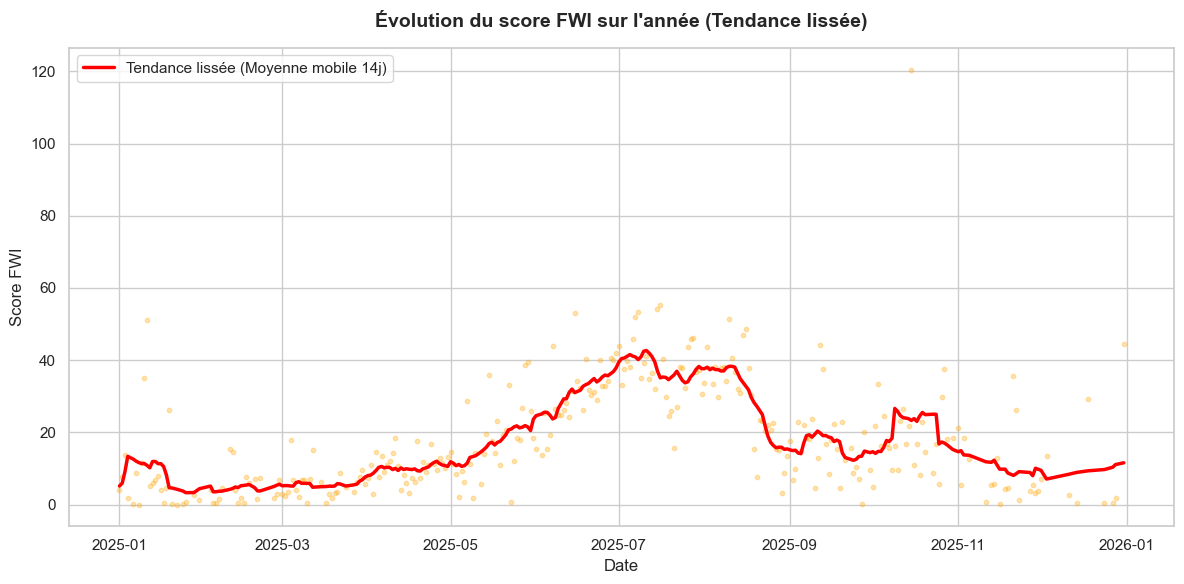

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_s = pd.read_csv("data.csv", sep=",", encoding="utf-8", parse_dates=['date'])

df_s = df_s.sort_values('date')


df_quotidien = df_s.groupby('date')['fwi'].mean().reset_index()


df_quotidien['fwi_lisse'] = df_quotidien['fwi'].rolling(window=14, min_periods=1, center=True).mean()


plt.figure(figsize=(12, 6))


plt.scatter(df_quotidien['date'], df_quotidien['fwi'], color='orange', alpha=0.3, s=10)


plt.plot(df_quotidien['date'], df_quotidien['fwi_lisse'], color='red', linewidth=2.5, label='Tendance lissée (Moyenne mobile 14j)')


plt.title("Évolution du score FWI sur l'année (Tendance lissée)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Score FWI", fontsize=12)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

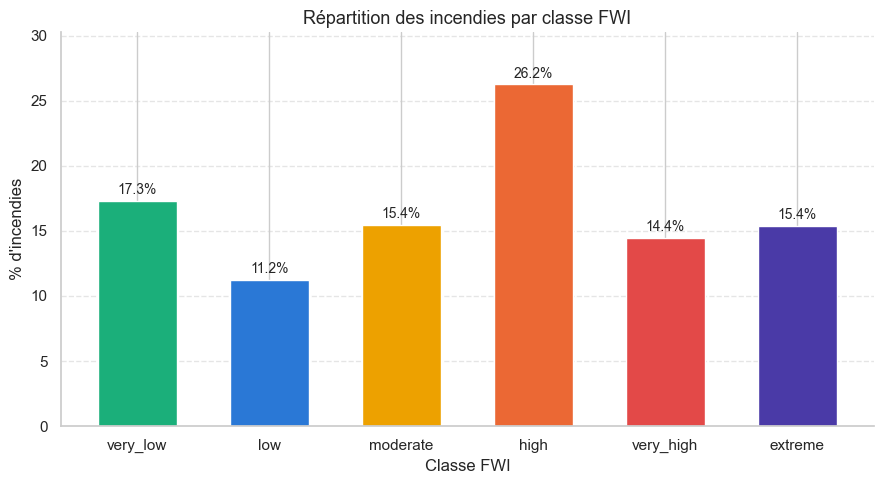

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data.csv")

# Ordre logique des classes
ordre = ["very_low", "low", "moderate", "high", "very_high", "extreme"]
couleurs = ["#1baf7a", "#2a78d6", "#eda100", "#eb6834", "#e34948", "#4a3aa7"]

# Calcul des pourcentages
counts = df["fwi_class"].value_counts()
pcts = (counts / len(df) * 100).reindex(ordre)

# Tracé
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(ordre, pcts, color=couleurs, width=0.6)

# Labels au-dessus des barres
for bar, val in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=10)

ax.set_xlabel("Classe FWI", fontsize=12)
ax.set_ylabel("% d'incendies", fontsize=12)
ax.set_title("Répartition des incendies par classe FWI", fontsize=13)
ax.set_ylim(0, pcts.max() + 4)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("fwi_distribution.png", dpi=150)
plt.show()